In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/salaries.csv')
df

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0
5,google,computer programmer,masters,1
6,abc pharma,sales executive,masters,0
7,abc pharma,computer programmer,bachelors,0
8,abc pharma,business manager,bachelors,0
9,abc pharma,business manager,masters,1


#### split the Data set:  Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

x = df.drop('salary_more_then_100k', axis=1)
y = df['salary_more_then_100k']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


### LabelEncoding : convert categorical data into numerical

In [17]:
from sklearn.preprocessing import LabelEncoder

le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()  

# Convert categorical to numerical
x_train['company_n'] = le_company.fit_transform(x_train['company'])
x_test['company_n'] = le_company.transform(x_test['company'])

x_train['job_n'] = le_job.fit_transform(x_train['job'])
x_test['job_n'] = le_job.transform(x_test['job'])

x_train['degree_n'] = le_degree.fit_transform(x_train['degree'])
x_test['degree_n'] = le_degree.fit_transform(x_test['degree']) 

# Drop original columns after encoding
x_train = x_train.drop(['company', 'job', 'degree'], axis=1)
x_test = x_test.drop(['company', 'job', 'degree'], axis=1)    


x_test

,company_n,job_n,degree_n
9,0,0,1
4,2,1,0
5,2,1,1
7,0,1,0


#### Train the Model

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier()

model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### predict the model on test data

In [22]:
y_pred = model.predict(x_test)

In [ ]:
# accuracy of your trained model on the test data.
#  how well your model performs on unseen (test) data.

model.score(x_test, y_test) 

0.5

#### model Evaluation


In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 50.00%


#### predict on New Data

In [37]:
# Example: Predict on new data
# Suppose you have a new candidate:
# company: "Google", job: "Sales Executive", degree: "Bachelors"

# First, encode the new data using the same label encoders
new_data = pd.DataFrame({
    'company': ['google'],
    'job': ['sales executive'],
    'degree': ['bachelors']
})

new_data['company_n'] = le_company.transform(new_data['company'])
new_data['job_n'] = le_job.transform(new_data['job'])
new_data['degree_n'] = le_degree.transform(new_data['degree'])

# Drop original columns to match training data
new_data_encoded = new_data.drop(['company', 'job', 'degree'], axis=1)

# Predict
prediction = model.predict(new_data_encoded)
print("Prediction (1 = >100k salary, 0 = <=100k salary):", prediction[0])

Prediction (1 = >100k salary, 0 = <=100k salary): 0


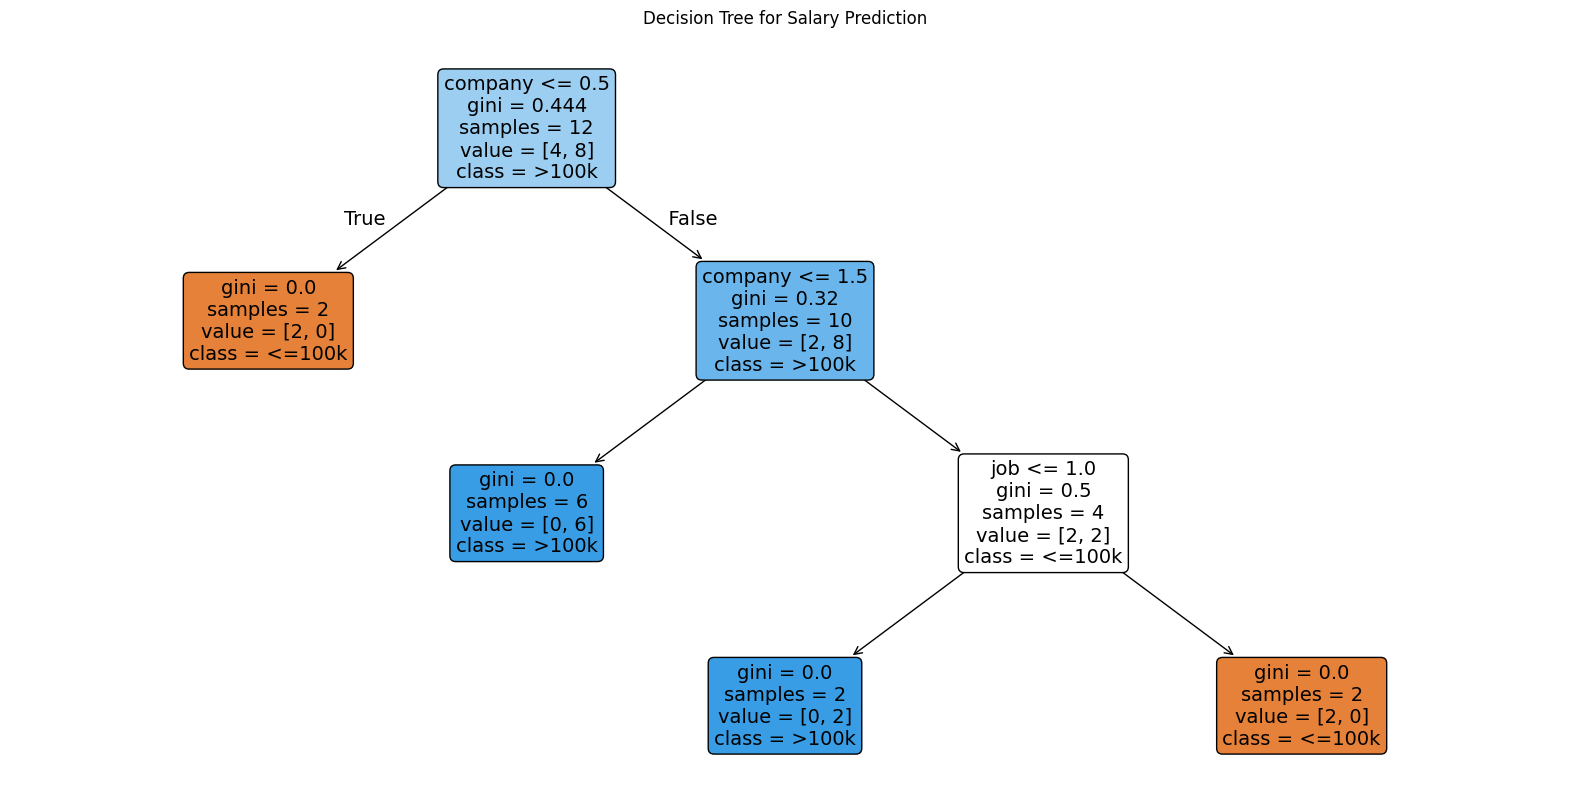

In [43]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=['<=100k', '>100k'],
    filled=True,
    rounded=True,
    fontsize=14
)
plt.title('Decision Tree for Salary Prediction')
plt.show()
